# Lecture 10: More on 2D Arrays

Welcome! Today we'll build on our 2D array knowledge and introduce some powerful tools and concepts:
- More advanced operations on 2D arrays
- Introduction to NumPy for efficient array operations
- The `break` statement for controlling loops

By the end of this lecture, you'll have more tools for working with grid-based data efficiently.

## Quick Review: 2D Arrays

Recall that a 2D array is a list of lists:

In [1]:
# A simple 3x4 grid
grid = [
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
]

print(f"Grid has {len(grid)} rows")
print(f"Each row has {len(grid[0])} columns")
print(f"Element at position (1, 2) is {grid[1][2]}")

Grid has 3 rows
Each row has 4 columns
Element at position (1, 2) is 7


And let's copy over the `pretty_print` function we created in last lecture:

In [2]:
def pretty_print(grid):
    """Pretty print a 2D array."""
    for row in grid:
        for value in row:
            print(f"{value:3d}", end=" ")
        print()

pretty_print(grid)

  1   2   3   4 
  5   6   7   8 
  9  10  11  12 


And the `show_image` function for displaying image 2D arrays:

In [3]:
from matplotlib import pyplot as plt

def show_image(image):
    plt.imshow(image, cmap="gray")
    plt.axis("off")

## Advanced Operations on 2D Arrays / Images

Last time, we did a practice exercise on how to add two arrays. Essentially, we can treat the arrays as matrices and do matrix algebra, like adding (or any other arithmetic operations) two matrices element wise.

Two other common matrix operations are:
- transpose: swapping rows and columns
- multiplication: the usual matrix multiplication.

### Transposing a 2D Array

**Transposing** means swapping rows and columns. Row `i` becomes column `i`.

This is useful when converting between different representations (e.g., row-major vs column-major ordering).

In [6]:
def transpose(array_2d):
    """
    Transpose a 2D array (swap rows and columns).
    
    Parameters:
        array_2d: 2D list
    
    Returns:
        transposed 2D list
    """
    num_rows = len(array_2d)
    num_cols = len(array_2d[0])
    
    # Create result with swapped dimensions
    # result = []
    # # TODO: your code here
    # # Start with a nested for loop
    # for col_index in range(num_cols):
    #     new_row = []
    #     for row_index in range(num_rows):
    #         new_row.append(array_2d[row_index][col_index])
    #     result.append(new_row)

    result = []
    for col_index in range(num_cols):
        new_row_placeholder = [0] * num_rows
        result.append(new_row_placeholder)
    # creates empty result array of num_cols x num_rows
    for row_index in range(num_rows):
        for col_index in range(num_cols):
            result[col_index][row_index] = array_2d[row_index][col_index]
    
    return result

# Test it
original = [
    [1, 2, 3],
    [4, 5, 6]
]

print("Original (2x3):")
pretty_print(original)

transposed = transpose(original)
print("\nTransposed (3x2):")
pretty_print(transposed)

Original (2x3):
  1   2   3 
  4   5   6 

Transposed (3x2):
  1   4 
  2   5 
  3   6 


### Multiplying 2D Arrays

#### Element-wise Multiplication

This is similar to the element-wise that we implemented last time.

In [7]:
def mult_2d_arrays(arr1, arr2):
    """
    Element-wise multiplication for 2D arrays.
    
    Parameters:
        arr1: the first 2D array
        arr2: the second 2D array
    
    Returns:
        a 2D array which is the product of the input arrays
    """
    num_rows = len(arr1)
    num_cols = len(arr1[0])

    result = []
    for row in range(num_rows):
        row_result = []
        for col in range(num_cols):
            row_result.append(arr1[row][col] * arr2[row][col])
        result.append(row_result)
    return result

# Test the implementation
arr1 = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]
arr2 = [
    [0, 0, 0],
    [1, 1, 1],
    [2, 2, 2]
]
# Expected output should be
# [[0, 0, 0],
#  [4, 5, 6],
#  [14, 16, 18]]

print("Calculating element-wise multiplication of arr1 and arr2")
print("arr1 =")
pretty_print(arr1)
print("arr2 =")
pretty_print(arr2)
mult_result = mult_2d_arrays(arr1, arr2)
print("\narr1 ⊙ arr2 =")
pretty_print(mult_result)

Calculating element-wise multiplication of arr1 and arr2
arr1 =
  1   2   3 
  4   5   6 
  7   8   9 
arr2 =
  0   0   0 
  1   1   1 
  2   2   2 

arr1 ⊙ arr2 =
  0   0   0 
  4   5   6 
 14  16  18 


#### Matrix Multiplication

Matrix multiplication is not done element-wise but instead, the resulting matrix's `i`th row and `j`th column is the dot product of the first matrix's `i`th row vector and the second matrix's `j`th column vector.

<img title="matrix multiplication" src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Matrix_multiplication_diagram_2.svg/1920px-Matrix_multiplication_diagram_2.svg.png" width="20%" />

The dot product is an element-wise multiplication then summation of two vectors. So in the figure above, the yellow cell ($r_{1,2}$) should hold the value of $a_{1,1}*b_{1,2} + a_{1,2}*b_{2,2}$, and the green cell ($r_{3,2}$) should hold the value of $a_{3,1}*b_{1,3} + a_{3,2}*b_{2,3}$.

In [8]:
def matrix_mult(arr1, arr2):
    """
    Matrix multiplication for 2D arrays.
    
    Parameters:
        arr1: the first 2D array
        arr2: the second 2D array
    
    Returns:
        a 2D array which is the matrix multiplcation of the input arrays
    """
    num_rows1 = len(arr1)
    num_cols1 = len(arr1[0])
    num_rows2 = len(arr2)
    num_cols2 = len(arr2[0])

    result = []
    for row1 in range(num_rows1):
        row_result = []
        for col2 in range(num_cols2):
            dot_product = 0
            for rc in range(num_cols1): # which should be equal to num_rows2
                dot_product += arr1[row1][rc] * arr2[rc][col2]
            row_result.append(dot_product)
        result.append(row_result)
    return result

# Test the implementation
arr1 = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]
arr2 = [
    [0, 0, 0],
    [1, 1, 1],
    [2, 2, 2]
]
# Expected output should be
# [[8, 8, 8],
#  [17, 17, 17],
#  [26, 26, 26]]

print("Calculating matrix multiplication of arr1 and arr2")
print("arr1 =")
pretty_print(arr1)
print("arr2 =")
pretty_print(arr2)
mult_result = matrix_mult(arr1, arr2)
print("\narr1 * arr2 =")
pretty_print(mult_result)

Calculating matrix multiplication of arr1 and arr2
arr1 =
  1   2   3 
  4   5   6 
  7   8   9 
arr2 =
  0   0   0 
  1   1   1 
  2   2   2 

arr1 * arr2 =
  8   8   8 
 17  17  17 
 26  26  26 


We also said that images naturally can be treated as a 2D array of pixels.

Some other image operations that can be done by manipulating the 2D arrays of pixels are:
- flipping the image horizontally or vertically
- cropping the image

### Flipping Arrays

Flipping horizontally or vertically is straightforward:

Original arrow (pointing left):


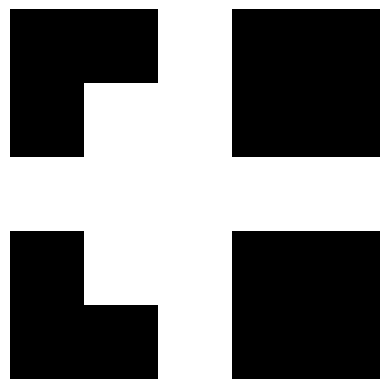

In [9]:
def flip_vertical(array_2d):
    """Flip array vertically (upside down)."""
    return array_2d[::-1]  # reverse the list of rows

def flip_horizontal(array_2d):
    """Flip array horizontally (mirror left-right)."""
    return [row[::-1] for row in array_2d]  # reverse each row

# Test
arrow = [
    [0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0]
]

print("Original arrow (pointing left):")
show_image(arrow)


Flipped horizontal (pointing right):


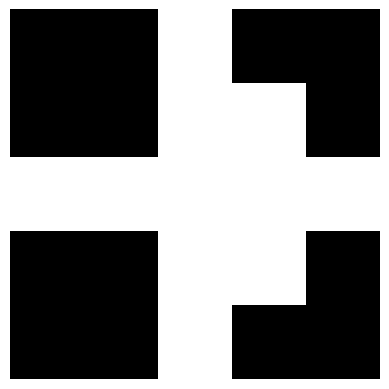

In [10]:
print("\nFlipped horizontal (pointing right):")
show_image(flip_horizontal(arrow))


Flipped vertical (no change due to symmetry):


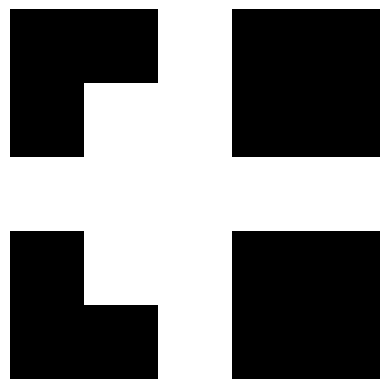

In [11]:
print("\nFlipped vertical (no change due to symmetry):")
show_image(flip_vertical(arrow))

### Cropping a 2D array

We can a rectangular region from a larger 2D array:

In [12]:
def crop(array_2d, start_row, end_row, start_col, end_col):
    """
    Crop a rectangular region from a 2D array.
    
    Parameters:
        array_2d: 2D list
        start_row, end_row: row range (inclusive, exclusive)
        start_col, end_col: column range (inclusive, exclusive)
    
    Returns:
        cropped 2D list
    """
    result = []
    for row in array_2d[start_row:end_row]:
        result.append(row[start_col:end_col])
    return result

# Test
big_grid = [
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20]
]

print("Original grid:")
pretty_print(big_grid)

# Extract center 2x2 region
center = crop(big_grid, 1, 3, 1, 3)
print("\nCenter 2x2:")
pretty_print(center)

Original grid:
  1   2   3   4   5 
  6   7   8   9  10 
 11  12  13  14  15 
 16  17  18  19  20 

Center 2x2:
  7   8 
 12  13 


## Introduction to NumPy

Ever wondered if Python might have some libraries for all these array operations? Yes, it's called **NumPy** (Numerical Python). NumPy provides optimized array operations and here instead of 2D arrays or nested lists, NumPy arrays are a bit more generalized and are called `ndarray` (n-dimensional array).

NumPy arrays are:
- Much faster for numerical operations
- More memory efficient
- Support vectorized operations (operations on entire arrays at once)

Let's import NumPy (typically imported as `np`) and try it out:

In [13]:
import numpy as np

### Creating NumPy Arrays

NumPy has convenient functions to create arrays:

In [14]:
# Array of zeros
zeros = np.zeros((3, 5))  # 3 rows, 5 columns
print("3x5 array of zeros:")
print(zeros)

3x5 array of zeros:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [15]:
# Array of ones
ones = np.ones((2, 3))
print("\n2x3 array of ones:")
print(ones)


2x3 array of ones:
[[1. 1. 1.]
 [1. 1. 1.]]


In [16]:
# Array filled with a specific value
fives = np.full((2, 2), 5)
print("\n2x2 array of fives:")
print(fives)


2x2 array of fives:
[[5 5]
 [5 5]]


In [18]:
type(fives)

numpy.ndarray

In [17]:
[[5, 5], [5, 5]]

[[5, 5], [5, 5]]

In [19]:
# Array of random integers
random_array = np.random.randint(0, 10, size=(3, 3))
print("\n3x3 array of random integers (0-9):")
print(random_array)


3x3 array of random integers (0-9):
[[4 3 0]
 [7 2 7]
 [7 5 3]]


If you already have a nested list defined, you can use that to initialize a NumPy array:

In [20]:
grid_np = np.array(grid)
print(type(grid))
print(type(grid_np))
grid_np

<class 'list'>
<class 'numpy.ndarray'>


array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

And of course you can also get a nested list from a NumPy array:

In [21]:
grid_np.tolist()

[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]]

### Vectorized Operations

The power of NumPy is that it provides utility functions and operators for all the things we implemented before, and its syntax works in a similar fashion as other sequences in Python like lists and strings.

We can take nested lists we defined before and see these operations' equivalents in NumPy:

In [22]:
original_np = np.array(original)

In [23]:
# transpose the array
original_np.T

array([[1, 4],
       [2, 5],
       [3, 6]])

In [24]:
arr1_np = np.array(arr1)
arr2_np = np.array(arr2)

In [25]:
# Adding two arrays
arr1_np + arr2_np

array([[ 1,  2,  3],
       [ 5,  6,  7],
       [ 9, 10, 11]])

In [26]:
# Multiplying two arrays
arr1_np * arr2_np

array([[ 0,  0,  0],
       [ 4,  5,  6],
       [14, 16, 18]])

In [27]:
# Matrix Multiplication
np.linalg.matmul(arr1_np, arr2_np)

array([[ 8,  8,  8],
       [17, 17, 17],
       [26, 26, 26]])

In [28]:
arrow_np = np.array(arrow)

In [29]:
# Flip Horizontally
np.fliplr(arrow_np)

array([[0, 0, 1, 0, 0],
       [0, 0, 1, 1, 0],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 1, 0],
       [0, 0, 1, 0, 0]])

In [30]:
# Flip Vertically
np.flipud(arrow_np)

array([[0, 0, 1, 0, 0],
       [0, 1, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [0, 1, 1, 0, 0],
       [0, 0, 1, 0, 0]])

In [31]:
big_grid_np = np.array(big_grid)

In [32]:
# Crop the image array, similar indexing except that the slices are connected with commas
big_grid_np[1:3, 1:3]

array([[ 7,  8],
       [12, 13]])

### When to Use NumPy

In this course, we will not be using NumPy but just with basic Python constructs like lists, but if you continue to take more computing courses or want to use Python programming to do scientific computation, NumPy will be very useful in your toolbox.

## The `break` Statement

Sometimes we want to **exit a loop early** when a certain condition is met. The `break` statement does exactly that: it immediately exits the *innermost* loop. And it works for both `for` loop and `while` loop.

### Basic Example

In [33]:
# Find the first number divisible by 7
for num in range(1, 100):
    if num % 7 == 0:
        print(f"Found it! {num} is divisible by 7")
        break  # exit the loop
    print(f"Checking {num}...")

print("Done searching!")

Checking 1...
Checking 2...
Checking 3...
Checking 4...
Checking 5...
Checking 6...
Found it! 7 is divisible by 7
Done searching!


In [ ]:
while True:
    if (condition):
        break

### Practical Example: Searching for a Value

We can use `break` to stop searching once we find what we're looking for:

In [ ]:
def find_in_list(items, target):
    """
    Find if target exists in items.
    Returns True if found, False otherwise.
    """
    for item in items:
        print(f"Checking {item}")
        if item == target:
            print(f"Found {target}!")
            return True
    print(f"{target} not found")
    return False

In [34]:
def find_in_list(items, target):
    """
    Find if target exists in items.
    """
    found = False
    for item in items:
        print(f"Checking {item}")
        if item == target:
            print(f"Found {target}!")
            found = True
            break
    if not found:
        print(f"{target} not found")

In [35]:
my_list = [1, 5, 3, 8, 2, 9]
# we find 8 and exit earlier
find_in_list(my_list, 8)

Checking 1
Checking 5
Checking 3
Checking 8
Found 8!


In [36]:
# we do not find 7 so we have to go over everything in the list
find_in_list(my_list, 7)

Checking 1
Checking 5
Checking 3
Checking 8
Checking 2
Checking 9
7 not found


### Using `break` with 2D Arrays

`break` only exits the innermost loop. For nested loops, this can be useful or be a source of bug.

In [37]:
def find_in_2d(array_2d, target):
    """
    Search for target in a 2D array.
    Returns (row, col) if found, None otherwise.
    """
    coordinate = None
    for row_idx in range(len(array_2d)):
        for col_idx in range(len(array_2d[row_idx])):
            if array_2d[row_idx][col_idx] == target: # found!
                coordinate = (row_idx, col_idx)
                break
    return coordinate

# Test
grid = [
    [1, 2, 3],
    [1, 2, 3],
    [1, 2, 3]
]

result = find_in_2d(grid, 1)
if result:
    print(f"Found at position {result}")
else:
    print("Not found")

Found at position (2, 0)


This currently finds the coordinate of the last occurrence of the target. What if we want to find the first occurrence? How would you modify this code?

In [ ]:
def find_first_in_2d(array_2d, target):
    """
    Search for the first occurrence of the target in a 2D array.
    Returns (row, col) if found, None otherwise.
    """
    coordinate = None
    for row_idx in range(len(array_2d)):
        for col_idx in range(len(array_2d[row_idx])):
            if array_2d[row_idx][col_idx] == target:
                coordinate = (row_idx, col_idx)
                return coordinate
    return coordinate

## Summary

Today we covered:
- advanced 2D array operations
- NumPy basics
- Loop control with `break`

Now we will go over more about how we actually write knitout code and some basic colorwork techniques. This will prepare you for Part 2 of HW3.